## ======================================================================
## 🧠 Hopify SaaS: Expansion Revenue by Segment over Time
## ======================================================================

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import pandas as pd
import seaborn as sns

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [3]:

file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "11_hopify_monthly_exp_rev_seg.csv"
)

df = pd.read_csv(file_path)

## ================================
## 🧼 Clean & Prepare Columns
## ================================

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("-", "_")
    .str.lower()
)

df['month'] = pd.to_datetime(df['month'], errors='coerce')
df = df.sort_values(['month', 'customer_segment'])

# Filter to most recent 12 months
latest_month = df['month'].max()
start_month = latest_month - pd.DateOffset(months=11)
df = df[(df['month'] >= start_month) & (df['month'] <= latest_month)]

df['quarter'] = df['month'].dt.to_period('Q').astype(str)
quarter_order = sorted(df['quarter'].unique(), reverse=True)
df['quarter'] = pd.Categorical(df['quarter'], categories=quarter_order, ordered=True)

segment_order = ["Enterprise", "Mid-Market", "SMB"]
df['customer_segment'] = pd.Categorical(df['customer_segment'], categories=segment_order, ordered=True)

## ==================================================
## 📊 Expansion Revenue Time-Series
## ==================================================

Text(0.5, 0.96, 'Expansion Revenue Trends by Segment')

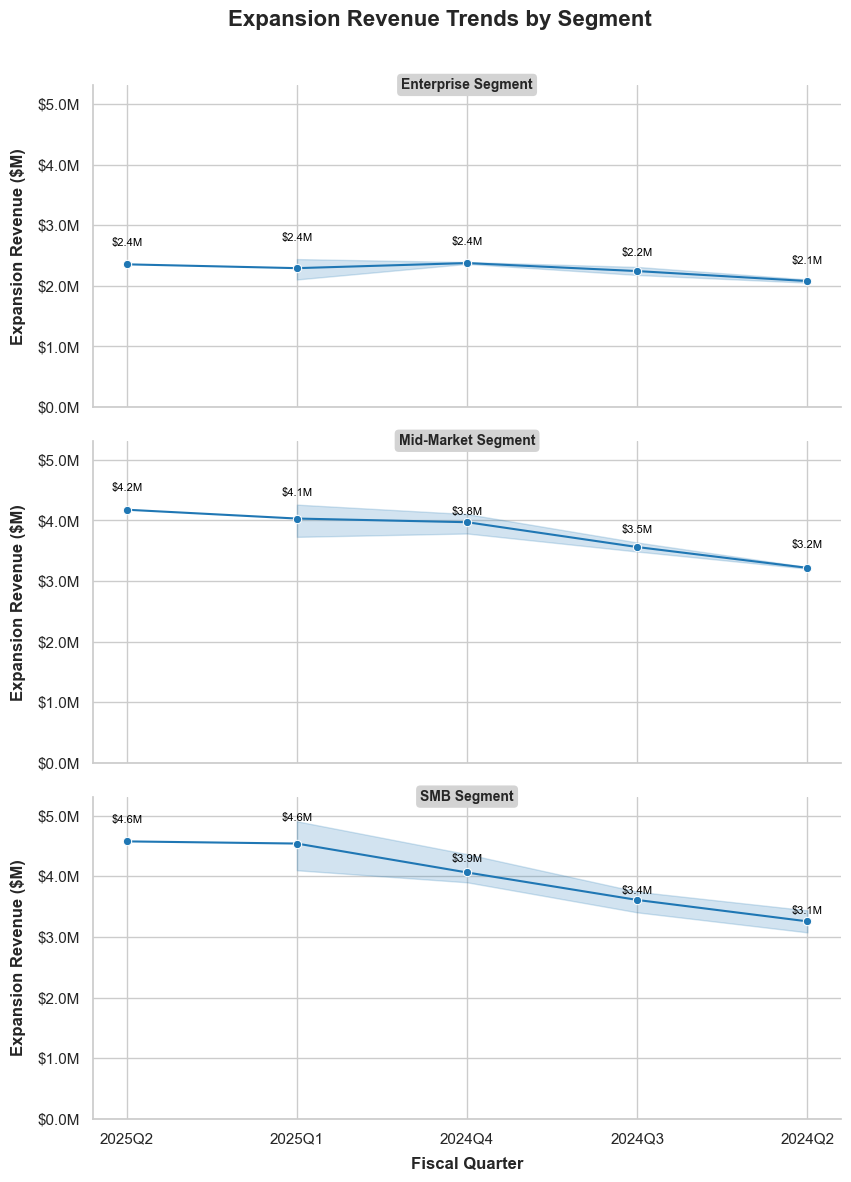

In [5]:
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="customer_segment", col_wrap=1, height=4.2, aspect=2, sharey=True)
g.map_dataframe(sns.lineplot, x="quarter", y="expansion_revenue", marker="o", color="#1f77b4")

# Format axes and annotate values
for ax, segment in zip(g.axes.flat, segment_order):
    seg_data = df[df['customer_segment'] == segment].drop_duplicates(subset=["quarter"])
    y_max = seg_data['expansion_revenue'].max()
    ax.set_ylim(0, y_max * 1.15)

    ax.yaxis.set_major_locator(MaxNLocator(nbins='auto', steps=[1, 2, 5, 10]))
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

    for _, row in seg_data.iterrows():
        ax.annotate(
            f"${row['expansion_revenue']/1e6:.1f}M",
            xy=(row['quarter'], row['expansion_revenue']),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8,
            color='black'
        )

    ax.set_title("")
    ax.text(
        0.5, 0.98, f"{segment} Segment",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', edgecolor='none')
    )

# Axis labels
g.set_axis_labels("Fiscal Quarter", "Expansion Revenue", fontweight='bold')
for ax in g.axes.flat:
    ax.set_xlabel("Fiscal Quarter", fontsize=12, fontweight='bold', labelpad=8)
    ax.set_ylabel("Expansion Revenue ($M)", fontsize=12, fontweight='bold', labelpad=8)

# Layout
g.fig.subplots_adjust(top=0.90, bottom=0.08)
g.fig.suptitle("Expansion Revenue Trends by Segment", fontsize=16, fontweight='bold', y=0.96)

## ================================
## 💾 Save & Display Plot
## ================================

In [6]:
output_path = os.path.join(BASE_PATH, "05_visuals", "hopify_expansion_revenue_seg.png")
plt.savefig(output_path, dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>